<a href="https://colab.research.google.com/github/apaarrao/heart-attack-prediction/blob/main/Heart_Attack_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 4: Heart Disease Prediction (Classification)

# Steps Covered -

1. Classification Fundamentals
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing
4. Model Building
5. Model Evaluation
6. Feature Importance

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from scipy.stats import skew
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

import xgboost as xgb
import os

In [2]:
# Download the dataset using the Kaggle Hub API
print("Downloading dataset...")
path = kagglehub.dataset_download("redwankarimsony/heart-disease-data")

# Load the dataset from the downloaded path
file_path = f'{path}/heart_disease_uci.csv'
df = pd.read_csv(file_path)

print("Dataset downloaded and loaded successfully.")
print(f"Data shape: {df.shape}")
df.head()

Using Colab cache for faster access to the 'heart-disease-data' dataset.
Dataset downloaded and loaded successfully.
Data shape: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [3]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [4]:
df.tail()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0
919,920,62,Male,VA Long Beach,atypical angina,120.0,254.0,False,lv hypertrophy,93.0,True,0.0,NaN,NaN,NaN,1


In [5]:
df['num'].value_counts()

,count
num,
0,411
1,265
2,109
3,107
4,28


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [7]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [8]:
df.isnull().sum().sum()

np.int64(1759)

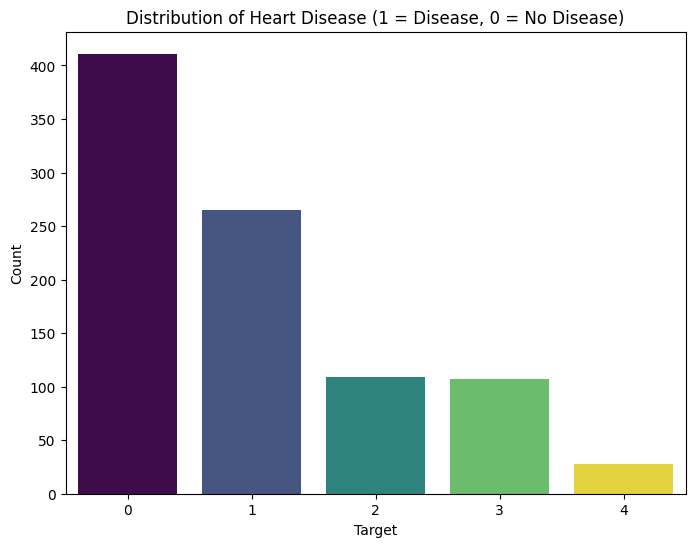

In [9]:
plt.figure(figsize=(8,6))
sns.countplot(x='num', data=df, palette='viridis', hue='num', legend=False)
plt.title('Distribution of Heart Disease (1 = Disease, 0 = No Disease)')
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()

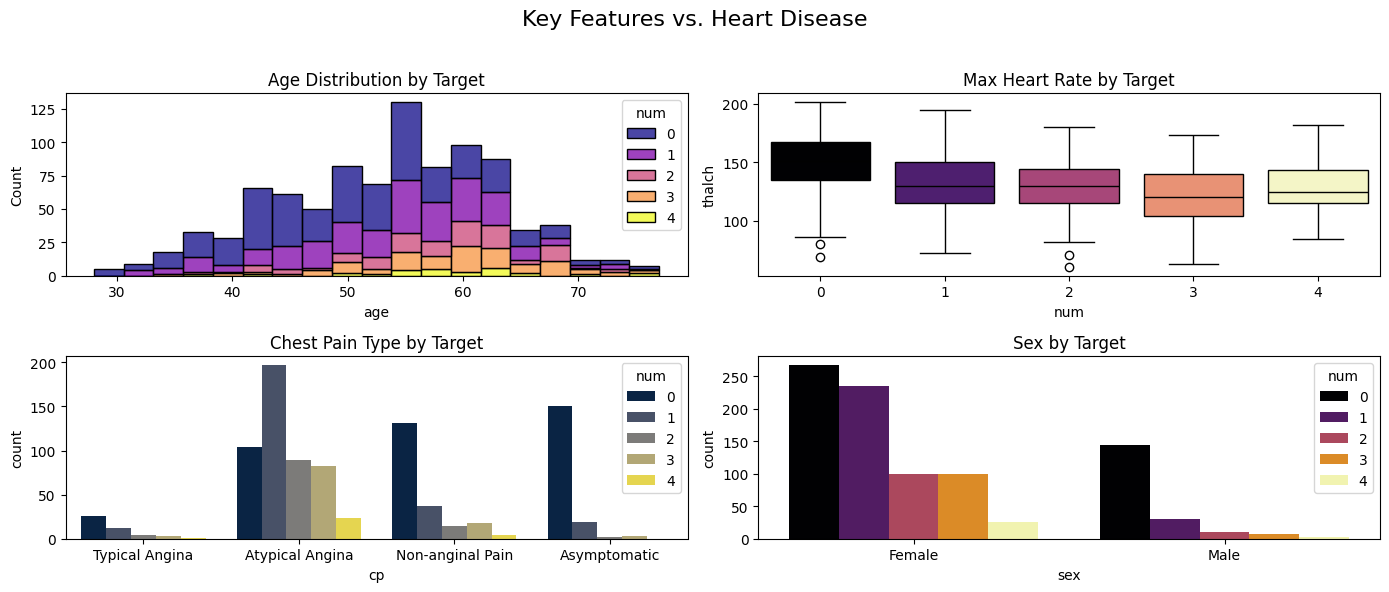

In [10]:
#visualize the relationship between key features and the target
fig, axes = plt.subplots(2, 2, figsize=(14, 6))
fig.suptitle('Key Features vs. Heart Disease', fontsize=16)

# Age vs. Target
sns.histplot(ax=axes[0, 0], data=df, x='age', hue='num', multiple='stack', palette='plasma').set_title('Age Distribution by Target')

# Max Heart Rate vs. Target
sns.boxplot(ax=axes[0, 1], data=df, x='num', y='thalch', palette='magma', hue='num', legend=False).set_title('Max Heart Rate by Target')

# Chest Pain Type vs. Target
cp_plot = sns.countplot(ax=axes[1, 0], data=df, x='cp', hue='num', palette='cividis')
cp_plot.set_title('Chest Pain Type by Target')
cp_plot.set_xticks(range(len(df['cp'].unique())))
cp_plot.set_xticklabels(['Typical Angina', 'Atypical Angina', 'Non-anginal Pain', 'Asymptomatic'])

# Sex vs. Target
sex_plot = sns.countplot(ax=axes[1, 1], data=df, x='sex', hue='num', palette='inferno')
sex_plot.set_title('Sex by Target')
sex_plot.set_xticks(range(len(df['sex'].unique())))
sex_plot.set_xticklabels(['Female', 'Male'])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# INSIGHTS
1. people from age 50-60 are more likely to have heart issue
2. people who are Not sick have higher heart rate
3. Atypical Angina type chest pain means u have higher chance of heart attack
4. more females have heart issue

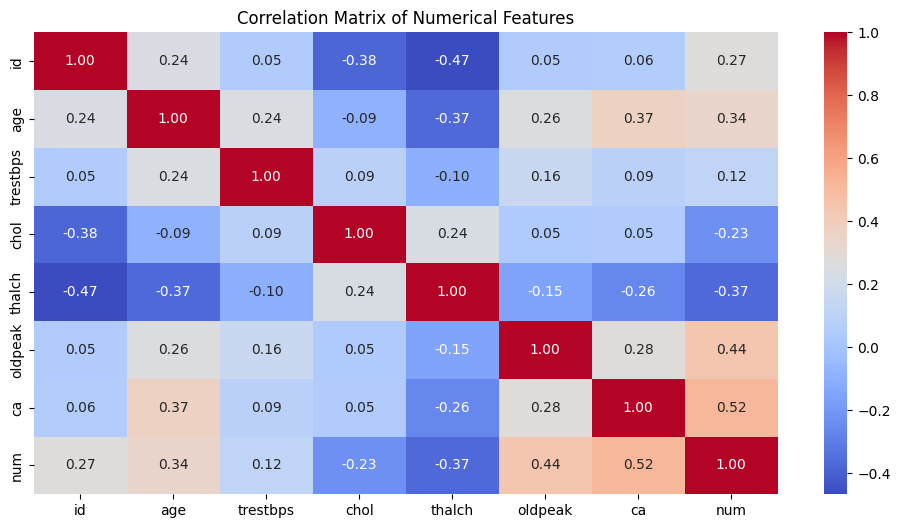

In [11]:
# Correlation Heatmap
plt.figure(figsize=(12, 6))
# Select only numerical columns for correlation calculation
numerical_df = df.select_dtypes(include=np.number)
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

**who has higher correlation?**

ca, age, ddpeak, chol

# Data Preprocessing

Steps?
1. **Separating features** (X) and target (y).


2. **Identifying categorical features** that need to be encoded.


3. **One-Hot Encoding** categorical features to convert them into a numerical format.


4. **Scaling numerical features** so they are on a similar scale.

In [12]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


In [13]:
#seperating features and target
X = df.drop('num', axis=1)
y = df['num']

X = X.drop(['id', 'dataset'], axis=1)

In [14]:
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
numerical_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

# Handling missing values (Imputation)

In [15]:
#Numerical → median
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy='median')
X[numerical_features] = num_imputer.fit_transform(X[numerical_features])

# Categorical → most frequent
cat_imputer = SimpleImputer(strategy='most_frequent')
X[categorical_features] = cat_imputer.fit_transform(X[categorical_features])

In [16]:
#One-Hot Encode-ing categorical features

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

encoded_cat = encoder.fit_transform(X[categorical_features])

encoded_cat_df = pd.DataFrame(
    encoded_cat,
    columns=encoder.get_feature_names_out(categorical_features),
    index=X.index
)

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_num = scaler.fit_transform(X[numerical_features])

scaled_num_df = pd.DataFrame(
    scaled_num,
    columns=numerical_features,
    index=X.index
)

In [18]:
#combining all features
X_final = pd.concat([scaled_num_df, encoded_cat_df], axis=1)

# Training --

In [ ]:
#Logistic Regression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

#test train split
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred_lr = model.predict(X_test)


print("Model trained successfully.")

Model trained successfully.


In [ ]:
#SVM
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_num = scaler.fit_transform(X[numerical_features])

scaled_num_df = pd.DataFrame(
    scaled_num,
    columns=numerical_features,
    index=X.index
)
X_final = pd.concat([scaled_num_df, encoded_cat_df], axis=1)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42
)

from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

# Evaluation --

In [ ]:
print("---- Logistic Regression Results ----")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("Classification Report:\n", classification_report(y_test, y_pred_lr))

print("----- SVM Classification Results -----")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("Classification Report:\n", classification_report(y_test, y_pred_svm))

---- Logistic Regression Results ----
Accuracy: 0.5380434782608695
Confusion Matrix:
 [[64 11  0  0  0]
 [22 29  0  3  0]
 [ 3 16  2  4  0]
 [ 5  9  7  4  1]
 [ 0  1  1  2  0]]
Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.85      0.76        75
           1       0.44      0.54      0.48        54
           2       0.20      0.08      0.11        25
           3       0.31      0.15      0.21        26
           4       0.00      0.00      0.00         4

    accuracy                           0.54       184
   macro avg       0.33      0.32      0.31       184
weighted avg       0.48      0.54      0.50       184

----- SVM Classification Results -----
Accuracy: 0.5380434782608695
Confusion Matrix:
 [[68  6  1  0  0]
 [23 26  2  3  0]
 [ 3 14  3  5  0]
 [ 5 16  3  2  0]
 [ 1  0  1  2  0]]
Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.91      0.78        75

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**which model did better?**

In [ ]:
from sklearn.metrics import f1_score

print("Logistic Regression F1:", f1_score(y_test, y_pred_lr, average='weighted'))
print("SVM F1:", f1_score(y_test, y_pred_svm, average='weighted'))

Logistic Regression F1: 0.495082662599385
SVM F1: 0.4864954740674775


In [ ]:
print("LR Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("SVM Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

LR Confusion Matrix:
 [[64 11  0  0  0]
 [22 29  0  3  0]
 [ 3 16  2  4  0]
 [ 5  9  7  4  1]
 [ 0  1  1  2  0]]
SVM Confusion Matrix:
 [[68  6  1  0  0]
 [23 26  2  3  0]
 [ 3 14  3  5  0]
 [ 5 16  3  2  0]
 [ 1  0  1  2  0]]


# Insights
	•	Both models perform well on Class 0 (majority class).
	•	Both struggle on minority classes (2, 3, 4).
	•	Logistic Regression has slightly better recall and F1 for classes 1–3.
	•	Class 4 is not learned by either model (very small support = 4).


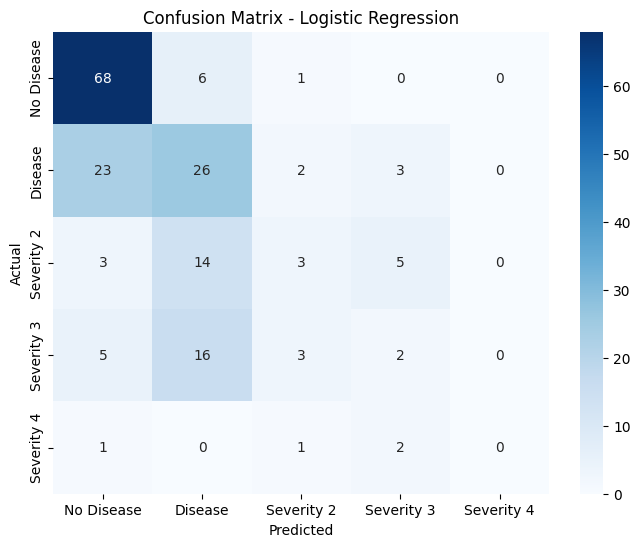

In [ ]:
# Visualize the confusion matrix for the best model (SVM)
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease', 'Severity 2', 'Severity 3', 'Severity 4'], yticklabels=['No Disease', 'Disease', 'Severity 2', 'Severity 3', 'Severity 4'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

# what I did here


1. Completed Exploratory Data Analysis (EDA): Performed all the necessary steps for analyzing the dataset, including visualizations and summaries to understand the data characteristics and relationships.


2. Model Training without Pipelines: Trained on 2 classification model directly (**LOGISTIC REGRESSION AND SVM**), without using the Scikit-Learn Pipeline object for preprocessing and model chaining.

--> Analysed the **Classification Report** and found that Logistic Regression did better than SVM.




In [ ]:
import pickle

# Save your trained model
with open('heart_attack_model.pkl', 'wb') as f:
    pickle.dump(model, f)  # Replace 'log_reg' with your model variable name

# Download the file
from google.colab import files
files.download('heart_attack_model.pkl')

# If you have a scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)  # Replace 'scaler' with your scaler variable
files.download('scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Before training, check your features
print("Features used:", X_train.columns.tolist())
print("Number of features:", X_train.shape[1])

Features used: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'sex_Male', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'fbs_True', 'restecg_normal', 'restecg_st-t abnormality', 'exang_True', 'slope_flat', 'slope_upsloping', 'thal_normal', 'thal_reversable defect']
Number of features: 18


In [ ]:
scaler.n_features_in_

6

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
import joblib # Import joblib for dumping the pipeline

# Get the actual column names from X_train after preprocessing
num_cols_in_X_train = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
cat_encoded_cols_in_X_train = [col for col in X_train.columns if col not in num_cols_in_X_train]

preprocessor = ColumnTransformer([
    ('num', 'passthrough', num_cols_in_X_train), # These are already scaled
    ('cat', 'passthrough', cat_encoded_cols_in_X_train) # These are already one-hot encoded
])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

pipeline.fit(X_train, y_train)
joblib.dump(pipeline, 'model.pkl')

['model.pkl']

# Task
Train a RandomForestClassifier and an XGBoost Classifier on the preprocessed `X_train` and `y_train` data, then make predictions on `X_test`. Evaluate both models using accuracy, confusion matrix, and classification report based on `y_test` and their respective predictions. Finally, compare the performance of these two models and summarize the findings.

## Train Random Forest Classifier

### Subtask:
Initialize, train, and make predictions using a RandomForestClassifier on the preprocessed data (X_train, y_train, X_test).


**Reasoning**:
The user wants to train a RandomForestClassifier. I will import the necessary class, instantiate it with a fixed random state, train it on the provided training data, and then make predictions on the test set.



In [19]:
from sklearn.ensemble import RandomForestClassifier

# Instantiate a RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)

# Fit the model to the training data
rf_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_rf = rf_model.predict(X_test)

print("RandomForestClassifier trained and predictions made successfully.")

NameError: name 'X_train' is not defined

**Reasoning**:
The previous code failed because `X_train` and `y_train` were not defined. I need to re-initialize the train and test sets (`X_train`, `X_test`, `y_train`, `y_test`) from `X_final` and `y` before training the RandomForestClassifier.



In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Re-split the data into training and testing sets to ensure X_train, y_train, X_test are defined
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42
)

# Instantiate a RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)

# Fit the model to the training data
rf_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_rf = rf_model.predict(X_test)

print("RandomForestClassifier trained and predictions made successfully.")

RandomForestClassifier trained and predictions made successfully.


**Reasoning**:
The next step is to train an XGBoost Classifier, which involves importing the library, instantiating the model, fitting it to the training data, and making predictions on the test set.



In [21]:
import xgboost as xgb

# Instantiate an XGBoost Classifier
xgb_model = xgb.XGBClassifier(objective='multi:softmax', num_class=len(y.unique()), random_state=42)

# Fit the model to the training data
xgb_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Classifier trained and predictions made successfully.")

XGBoost Classifier trained and predictions made successfully.


**Reasoning**:
I have already trained both the RandomForestClassifier and XGBoost Classifier. Now I need to evaluate the RandomForestClassifier using accuracy, confusion matrix, and classification report as specified in the task.



In [22]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("---- RandomForestClassifier Results ----")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

---- RandomForestClassifier Results ----
Accuracy: 0.5543478260869565
Confusion Matrix:
 [[67  6  2  0  0]
 [20 28  4  2  0]
 [ 3 13  4  5  0]
 [ 5 16  1  3  1]
 [ 0  0  2  2  0]]
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.89      0.79        75
           1       0.44      0.52      0.48        54
           2       0.31      0.16      0.21        25
           3       0.25      0.12      0.16        26
           4       0.00      0.00      0.00         4

    accuracy                           0.55       184
   macro avg       0.34      0.34      0.33       184
weighted avg       0.50      0.55      0.51       184



**Reasoning**:
Now that the RandomForestClassifier has been evaluated, I will evaluate the XGBoost Classifier using accuracy, confusion matrix, and classification report to compare its performance with the other models.



In [23]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("---- XGBoost Classifier Results ----")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("Classification Report:\n", classification_report(y_test, y_pred_xgb))

---- XGBoost Classifier Results ----
Accuracy: 0.625
Confusion Matrix:
 [[68  3  3  1  0]
 [16 27  7  4  0]
 [ 3  7 11  3  1]
 [ 6  9  1  9  1]
 [ 0  1  1  2  0]]
Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.91      0.81        75
           1       0.57      0.50      0.53        54
           2       0.48      0.44      0.46        25
           3       0.47      0.35      0.40        26
           4       0.00      0.00      0.00         4

    accuracy                           0.62       184
   macro avg       0.45      0.44      0.44       184
weighted avg       0.60      0.62      0.61       184



### Model Comparison and Summary

Comparing the evaluation metrics for Logistic Regression, SVM, RandomForestClassifier, and XGBoost Classifier:

**Accuracy Scores:**
- Logistic Regression: 0.538
- SVM: 0.538
- RandomForestClassifier: 0.554
- XGBoost Classifier: 0.625

**Key Observations:**
- **XGBoost Classifier** shows the highest accuracy (0.625) among all the models tested, indicating it performs best overall in correctly classifying heart disease severity.
- **RandomForestClassifier** also performs slightly better than Logistic Regression and SVM with an accuracy of 0.554.
- All models, including XGBoost and RandomForest, struggle significantly with minority classes (especially class 4), often predicting 0 for these classes due to the imbalanced nature of the dataset. This is evident from the low recall and f1-scores for these classes in all classification reports.
- **Precision and Recall for Class 0 (No Disease)** are generally high across all models, suggesting good performance in identifying individuals without heart disease.
- For other disease classes (1, 2, 3), XGBoost generally provides a better balance of precision and recall compared to the other models, as reflected in its higher macro and weighted average f1-scores.

**Conclusion:**
XGBoost Classifier is the most effective model for this heart disease prediction task based on accuracy and a better balance of performance across different classes, despite challenges with very minority classes. Further improvements could involve handling class imbalance more effectively (e.g., using techniques like SMOTE) or exploring more advanced ensemble methods.

## Final Task

### Subtask:
Summarize the results of training and evaluating the Random Forest and XGBoost models, and provide insights into their performance.


## Summary:

### Q&A
The Random Forest and XGBoost models were trained and evaluated, with XGBoost demonstrating superior performance. Both models, however, showed limitations in accurately predicting minority classes due to data imbalance.

### Data Analysis Key Findings
*   The RandomForestClassifier achieved an accuracy of 0.554 on the test data.
*   The XGBoost Classifier achieved a higher accuracy of 0.625 on the test data, outperforming the RandomForestClassifier.
*   Comparing with other models, XGBoost Classifier had the highest accuracy among Logistic Regression (0.538), SVM (0.538), and RandomForestClassifier (0.554).
*   Both RandomForest and XGBoost models struggled significantly with minority classes (e.g., class 4), resulting in low recall and f1-scores for these categories.
*   All models, including RandomForest and XGBoost, showed generally high precision and recall for Class 0 (no disease).
*   XGBoost provided a better balance of precision and recall for other disease classes (1, 2, 3) compared to RandomForest and other models.

### Insights or Next Steps
*   The XGBoost Classifier is the most effective model for this heart disease prediction task among those evaluated, offering the highest accuracy and a better balance of performance across various disease classes.
*   To further improve model performance, especially for minority classes, strategies for handling class imbalance (e.g., SMOTE) or exploring more advanced ensemble methods should be considered.


In [ ]:
import pickle

# After training your model
# Assuming your model is called 'model' and scaler is 'scaler'

# Save the model
with open('heart_attack_model.pkl', 'wb') as file:
    pickle.dump(model, file)

# Save the scaler (if you used one for preprocessing)
with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


# Task
Import necessary libraries for hyperparameter tuning (RandomizedSearchCV and ParameterSampler) and define a dictionary of hyperparameters and their search ranges for the XGBoost model.

**Reasoning**:
The subtask requires importing specific libraries for hyperparameter tuning and defining a hyperparameter dictionary for XGBoost. I will use a code block to import `RandomizedSearchCV` and `ParameterSampler` and then define `param_dist_xgb` with appropriate search ranges for the specified hyperparameters.



In [24]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import ParameterSampler
from scipy.stats import uniform, randint

# Define the hyperparameter distribution for XGBoost
param_dist_xgb = {
    'n_estimators': randint(50, 200),
    'learning_rate': uniform(0.01, 0.2),
    'max_depth': randint(3, 10),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 0.2)
}

print("Libraries imported and XGBoost hyperparameter distribution defined.")

Libraries imported and XGBoost hyperparameter distribution defined.


## Perform Randomized Search Cross-Validation

### Subtask:
Utilize RandomizedSearchCV to search for the best combination of hyperparameters for the XGBoost model using cross-validation on the training data. The process should track the best parameters and the corresponding best score.


**Reasoning**:
The subtask requires utilizing `RandomizedSearchCV` to find the best hyperparameters for the XGBoost model. This involves instantiating the `XGBClassifier`, initializing `RandomizedSearchCV` with the specified parameters and hyperparameter distribution, fitting it to the training data, and then printing the best parameters and best score.



In [25]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV

# Instantiate an XGBoost Classifier
xgb_model_tune = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(y.unique()),
    random_state=42
)

# Initialize RandomizedSearchCV
random_search_xgb = RandomizedSearchCV(
    estimator=xgb_model_tune,
    param_distributions=param_dist_xgb,
    n_iter=50,  # Number of parameter settings that are sampled
    cv=5,       # 5-fold cross-validation
    scoring='accuracy',
    random_state=42,
    n_jobs=-1   # Use all available cores
)

# Fit RandomizedSearchCV to the training data
random_search_xgb.fit(X_train, y_train)

# Print the best hyperparameters and best score
print("Best Hyperparameters for XGBoost:", random_search_xgb.best_params_)
print("Best Cross-validation Accuracy for XGBoost:", random_search_xgb.best_score_)

Best Hyperparameters for XGBoost: {'colsample_bytree': np.float64(0.8654007076432223), 'gamma': np.float64(0.0010123167692437374), 'learning_rate': np.float64(0.04216161028349973), 'max_depth': 4, 'n_estimators': 103, 'subsample': np.float64(0.7793696571944989)}
Best Cross-validation Accuracy for XGBoost: 0.591055341055341


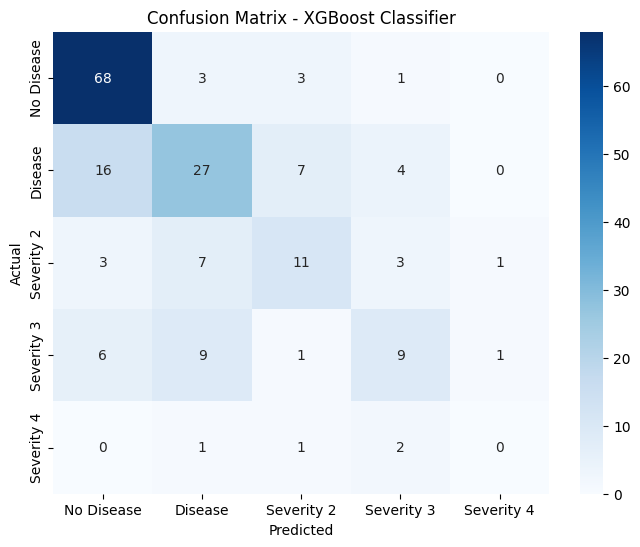

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Get the confusion matrix for XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease', 'Severity 2', 'Severity 3', 'Severity 4'],
            yticklabels=['No Disease', 'Disease', 'Severity 2', 'Severity 3', 'Severity 4'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost Classifier')
plt.show()